# Annotation

In [2]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

from numba.core.errors import NumbaDeprecationWarning

warnings.simplefilter("ignore", category=NumbaDeprecationWarning)

In [3]:
import urllib.request
from pathlib import Path

import celltypist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

# the environment variable SCIPY_ARRAY_API needs to be set to 1 before importing either Scikit-learn or SciPy
import os
os.environ['SCIPY_ARRAY_API']='1'

import scarches as sca
import seaborn as sns
from celltypist import models
from scipy.sparse import csr_matrix

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

sc.set_figure_params(figsize=(5, 5))

In order to use the mouse gastrulation seqFISH datsets, please install squidpy (see https://github.com/scverse/squidpy).
/opt/conda/envs/annotation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/annotation/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/opt/conda/envs/annotation/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
In order to use sagenet models, please install pytorch geometric (see https://pytorch-geometric.readthedocs.io) and 
 captum (see https://github.com/pytorch/captum).
mvTCR is not installed. To use mvTCR 

In [4]:
import anndata
adata = anndata.read_h5ad("../clustering/clustering.h5ad.gz")
adata

AnnData object with n_obs × n_vars = 892 × 236796
    obs: 'sample', 'fastq_1', 'fastq_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'size_factors', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res1_25'
    var: 'gene_versions', 'gene_symbol', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_25', 'leiden_res1_25_colors', '

## Annotation from cluster differentially expressed marker genes

In [27]:
# calculate the 1 vs. all differentially expressed genes for each cluster
sc.tl.rank_genes_groups(
    adata, groupby="leiden_res1_25", method="wilcoxon", key_added="dea_leiden_res1_25", tie_correct=True, rankby_abs=True
)

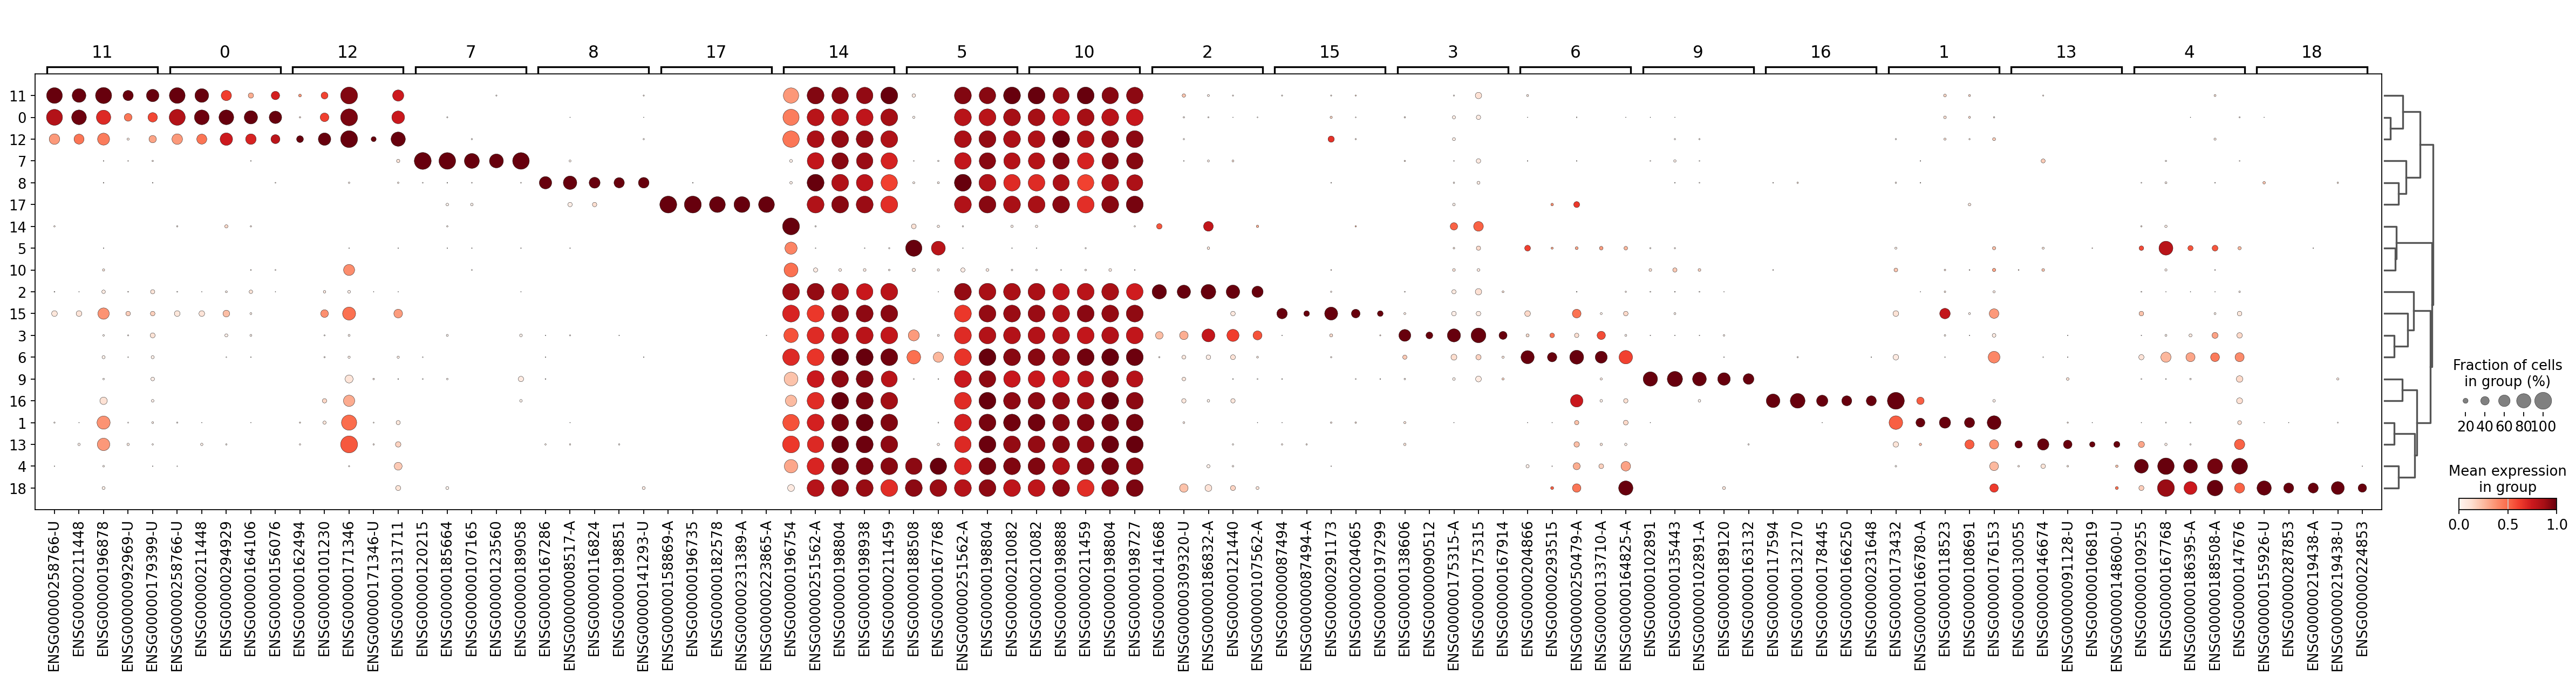

In [28]:
# visualize top DEGs per cluster with a dotplot
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden_res1_25", standard_scale="var", n_genes=5, key="dea_leiden_res1_25"
)

In [29]:
adata

AnnData object with n_obs × n_vars = 892 × 236796
    obs: 'sample', 'fastq_1', 'fastq_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'size_factors', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res1_25'
    var: 'gene_versions', 'gene_symbol', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_25', 'leiden_res1_25_colors', '

In [35]:
# filter the differentially expressed genes to select for more cluster-specific differentially expressed genes
sc.tl.filter_rank_genes_groups(adata,key="dea_leiden_res1_25",key_added="leiden_res1_25_filtered",min_in_group_fraction=0.2,max_out_group_fraction=0.2)

AttributeError: 'Series' object has no attribute 'nonzero'

In [ ]:
# visualize the filtered genes
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="leiden_res1_25",
    standard_scale="var",
    n_genes=5,
    key="leiden_res1_25_filtered",
)

In [43]:
gene_dict = dict(zip(adata.var_names, adata.var['gene_symbol']))

In [44]:
gene_dict['ENSG00000258766-U']

nan

In [49]:
df = pd.DataFrame(adata.uns["dea_leiden_res1_25"]["names"]).head(5)
df2 = df.loc[0:5, :]
df2.replace(gene_dict)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,NaN,SAA1,CBLN2,SHF,NMU,KRTDAP,IGFL2,MLANA,CD3D,MT4,MT-RNR2,NaN,LRRC38,GDPD2,S100A2,PTHLH,HSD11B1,NaN,NaN
1,DIO2,NaN,NaN,FETUB,KRT1,KRT1,NaN,PMEL,NaN,KRT85,MT-ND1,DIO2,ISM1,IGFBP3,NaN,NaN,PPARG,HLA-DQA1,NaN
2,NaN,CTGF,NaN,NaN,NaN,NaN,NaN,TYRP1,CD2,NaN,MT-RNR1,LAMB3,KRT15,NaN,MT-CO1,NaN,GLDC,CSF1R,NaN
3,SCRG1,CCL2,PDZRN3,CST6,NaN,MT-CO1,NaN,PLP1,CD3E,SP6,MT-CO1,NaN,NaN,ASPN,MT-CO3,TCEAL5,CLMP,NaN,NaN
4,WIF1,GPX2,NaN,GSDMA,MAL2,MT-RNR2,NaN,APOD,NaN,MSX1,MT-CYB,NaN,MAP1B,NaN,MT-RNR1,BLM,RP11-372M18.2,NaN,LINC00393


### Subset of genes with valid gene symbols (excludes unstable and alternative genes)

In [5]:
adata.var['na_genes'] = adata.var['gene_symbol'].isna()
adata_sym = adata[:, ~adata.var['na_genes']]
adata_sym.var_names = adata_sym.var['gene_symbol'].values.astype(str)
adata_sym.var_names_make_unique()

In [6]:
# calculate the 1 vs. all differentially expressed genes for each cluster
sc.tl.rank_genes_groups(
    adata_sym, groupby="leiden_res1_25", method="wilcoxon", key_added="dea_leiden_res1_25", tie_correct=True, rankby_abs=False
)

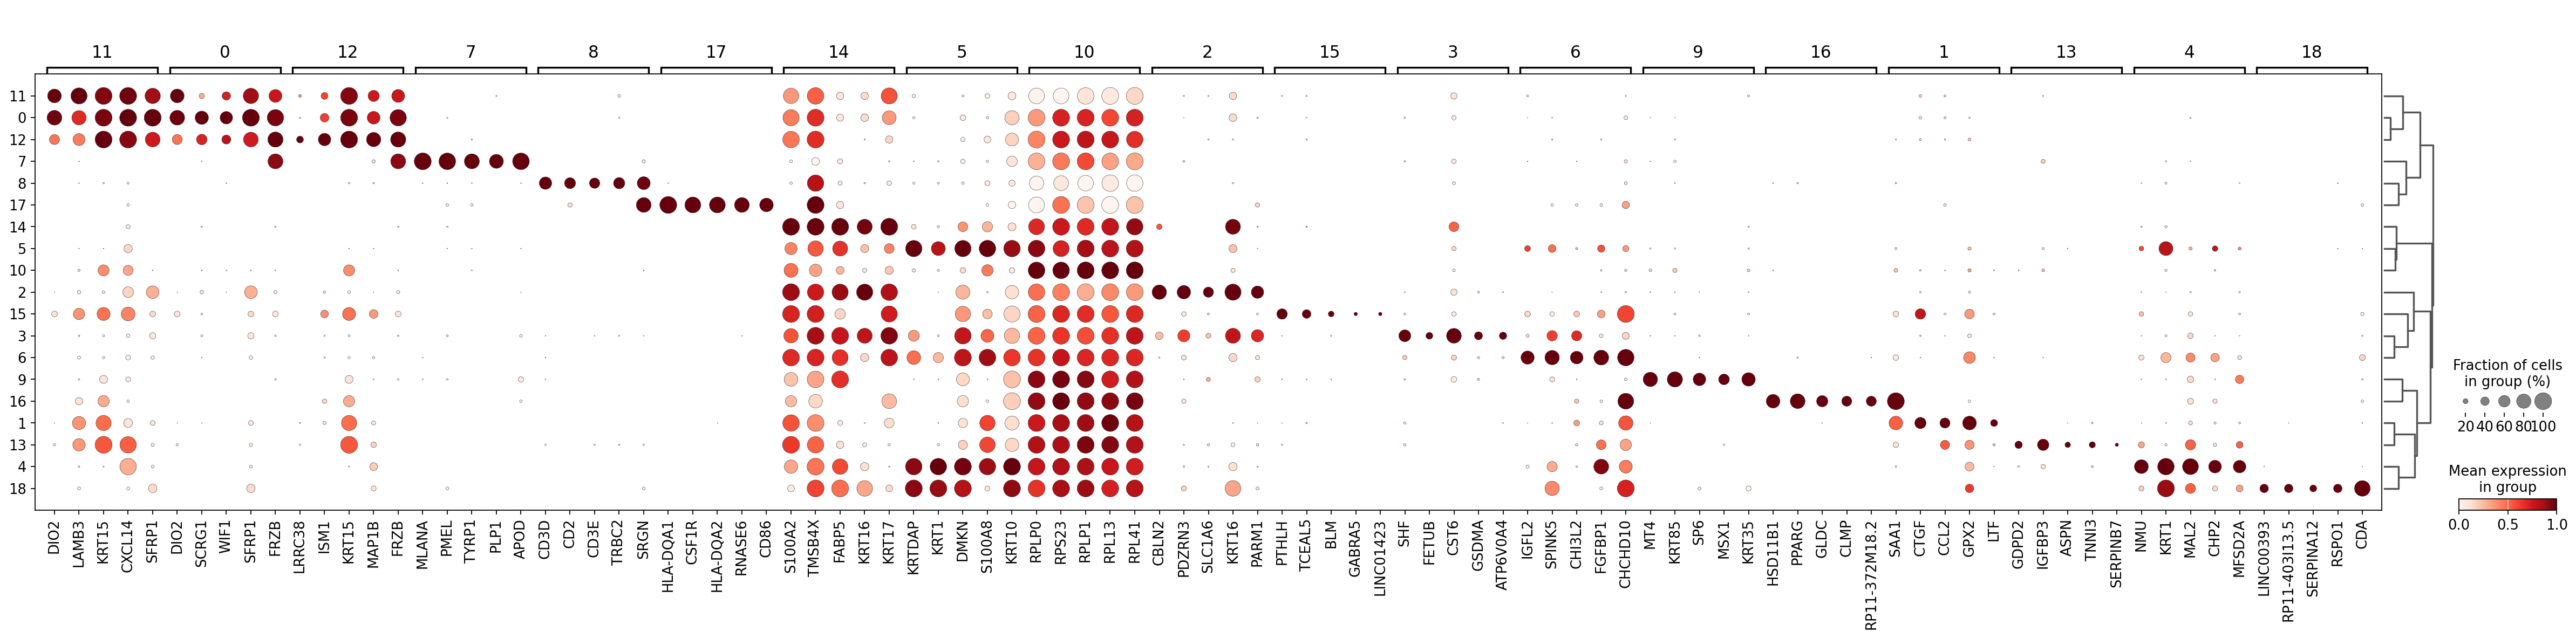

In [7]:
# visualize top DEGs per cluster with a dotplot
sc.pl.rank_genes_groups_dotplot(
    adata_sym, groupby="leiden_res1_25", standard_scale="var", n_genes=5, key="dea_leiden_res1_25"
)

In [8]:
pd.DataFrame(adata_sym.uns["dea_leiden_res1_25"]["names"]).head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,DIO2,SAA1,CBLN2,SHF,NMU,KRTDAP,IGFL2,MLANA,CD3D,MT4,RPLP0,DIO2,LRRC38,GDPD2,S100A2,PTHLH,HSD11B1,HLA-DQA1,LINC00393
1,SCRG1,CTGF,PDZRN3,FETUB,KRT1,KRT1,SPINK5,PMEL,CD2,KRT85,RPS23,LAMB3,ISM1,IGFBP3,TMSB4X,TCEAL5,PPARG,CSF1R,RP11-403I13.5
2,WIF1,CCL2,SLC1A6,CST6,MAL2,DMKN,CHI3L2,TYRP1,CD3E,SP6,RPLP1,KRT15,KRT15,ASPN,FABP5,BLM,GLDC,HLA-DQA2,SERPINA12
3,SFRP1,GPX2,KRT16,GSDMA,CHP2,S100A8,FGFBP1,PLP1,TRBC2,MSX1,RPL13,CXCL14,MAP1B,TNNI3,KRT16,GABRA5,CLMP,RNASE6,RSPO1
4,FRZB,LTF,PARM1,ATP6V0A4,MFSD2A,KRT10,CHCHD10,APOD,SRGN,KRT35,RPL41,SFRP1,FRZB,SERPINB7,KRT17,LINC01423,RP11-372M18.2,CD86,CDA


## CellTypist automated annotation using Adult_Human_Skin model

In [5]:
adata.var['na_genes'] = adata.var['gene_symbol'].isna()
adata_sym = adata[:, ~adata.var['na_genes']]
adata_sym.var_names = adata_sym.var['gene_symbol']

In [7]:
adata_celltypist = adata_sym.copy()  # make a copy of our adata
adata_celltypist.X = adata_sym.layers["counts"]  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

In [8]:
models.download_models(
    force_update=True, model=["Adult_Human_Skin.pkl"]
)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 54
📂 Storing models in /home/vscode/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Adult_Human_Skin.pkl


In [9]:
model = models.Model.load(model="Adult_Human_Skin.pkl")

In [10]:
model.cell_types

array(['DC1', 'DC2', 'Differentiated_KC', 'F1', 'F2', 'F3', 'ILC1_3',
       'ILC1_NK', 'ILC2', 'Inf_mac', 'LC', 'LE1', 'LE2', 'Macro_1',
       'Macro_2', 'Mast_cell', 'Melanocyte', 'MigDC', 'Mono_mac', 'NK',
       'Pericyte_1', 'Pericyte_2', 'Plasma', 'Schwann_1', 'Schwann_2',
       'Tc', 'Th', 'Treg', 'Undifferentiated_KC', 'VE1', 'VE2', 'VE3',
       'migLC', 'moDC'], dtype=object)

In [11]:
predictions = celltypist.annotate(
    adata_celltypist, model=model, majority_voting=True
)

🔬 Input data has 892 cells and 56134 genes
🔗 Matching reference genes in the model


🧬 3190 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [13]:
# transform predictions to AnnData object
predictions_adata = predictions.to_adata()

# copy the results to the original AnnData object
adata.obs["celltypist_cell_label"] = predictions_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score"] = predictions_adata.obs.loc[
    adata.obs.index, "conf_score"
]

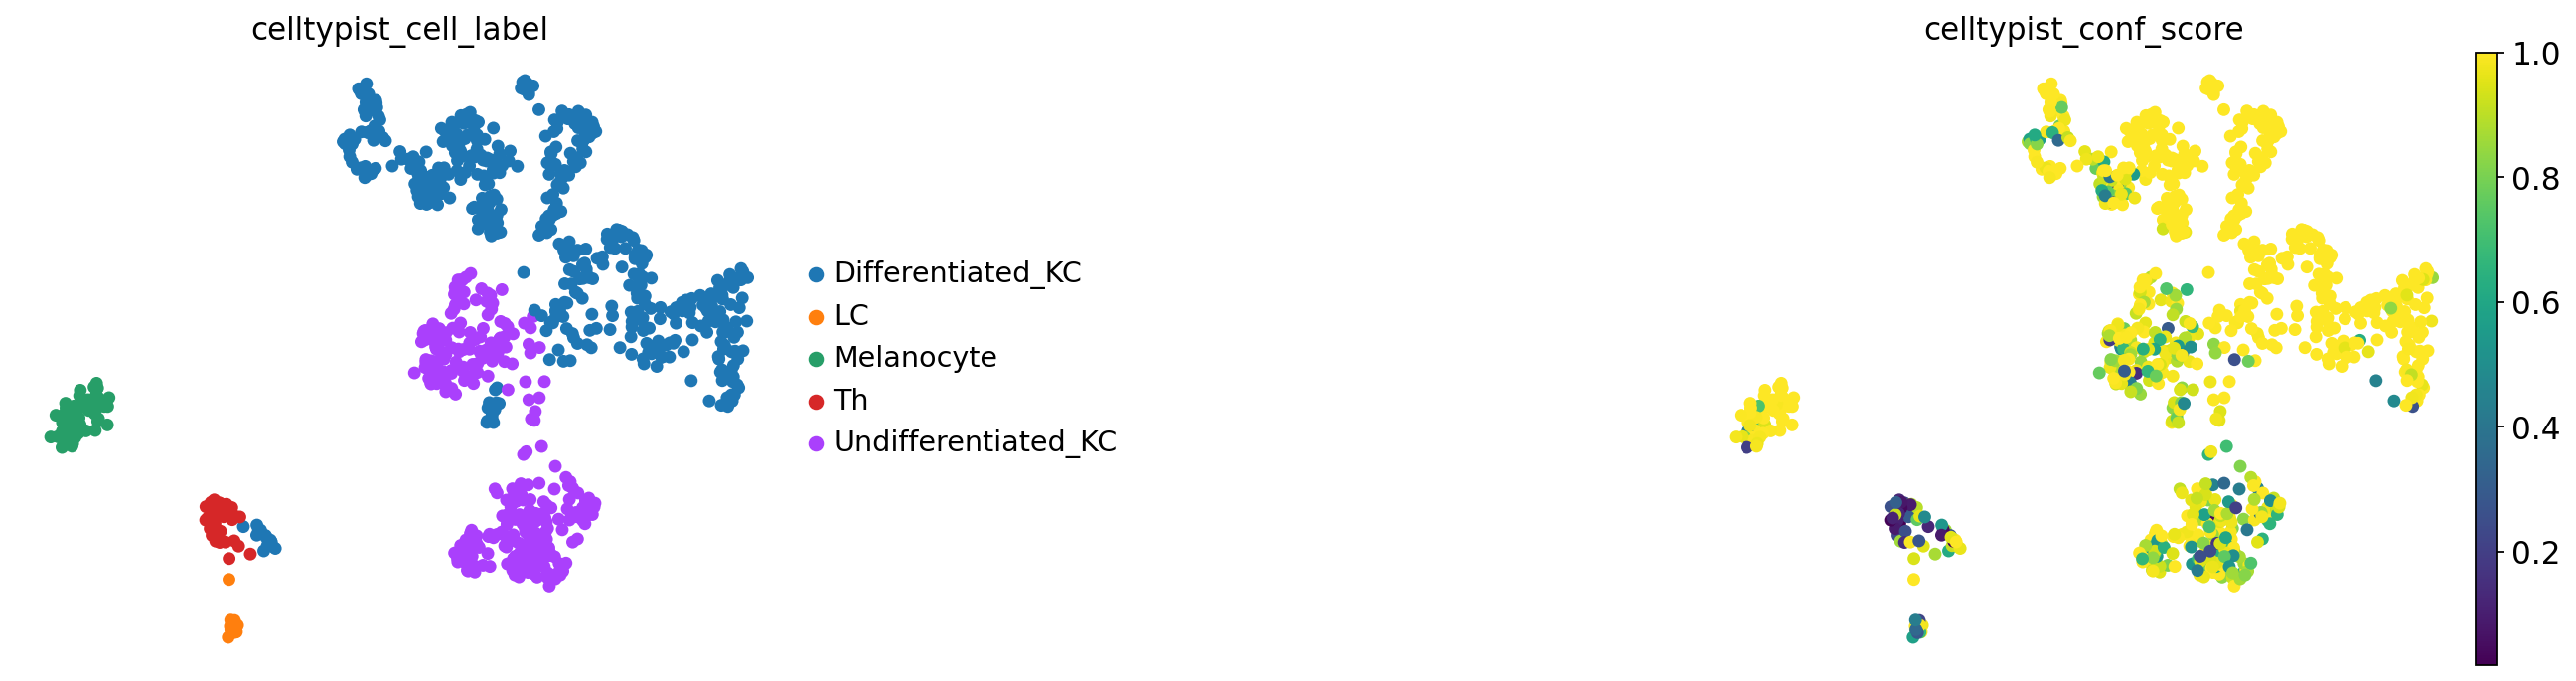

In [14]:
# plot results
sc.pl.umap(
    adata,
    color=["celltypist_cell_label", "celltypist_conf_score"],
    frameon=False,
    sort_order=False,
    wspace=1,
)

In [17]:
pd.crosstab(adata.obs.leiden_res1_25, adata.obs.celltypist_cell_label)

celltypist_cell_label,Differentiated_KC,LC,Melanocyte,Th,Undifferentiated_KC
leiden_res1_25,,,,,
0,0,0,0,0,102
1,0,0,0,0,91
2,88,0,0,0,0
3,67,0,0,0,0
4,64,0,0,0,0
5,62,0,0,0,0
6,57,0,0,0,0
7,0,0,53,0,0
8,15,1,0,34,0


In [36]:
adata.obs.leiden_res1_25

GCATGTACAATCTACG_Hair_graft_5_emptydrops_filter     3
CATCGAAGTTCCAACA_Hair_graft_5_emptydrops_filter     4
CCAGCGATCCGAACGC_Hair_graft_5_emptydrops_filter     6
GAAATGATCAATACCG_Hair_graft_5_emptydrops_filter     6
GTACTTTCAACAACCT_Hair_graft_5_emptydrops_filter     6
                                                   ..
GGCTCGAAGAGCTATA_Hair_graft_5_emptydrops_filter    10
GGTATTGAGAGGTAGA_Hair_graft_5_emptydrops_filter    10
CTGAAACCAAGCTGGA_Hair_graft_5_emptydrops_filter    11
CTACACCCATCACGAT_Hair_graft_5_emptydrops_filter     7
TTGAACGGTTCGCTAA_Hair_graft_5_emptydrops_filter    10
Name: leiden_res1_25, Length: 892, dtype: category
Categories (19, object): ['0', '1', '2', '3', ..., '15', '16', '17', '18']